# Projet Data Science - Composition nutritionnelle des produits USDA

**Date : 20/09/2026**

## Problématique
- Quelles sont les caractéristiques nutritionnelles des produits référencés dans la base USDA ?
- Quelles relations existent entre les nutriments et les autres variables quantitatives ?
- Peut-on dresser un profil synthétique des produits avec une analyse en composantes principales (ACP) ?

L'analyse porte sur les valeurs nutritionnelles pour 100 g de produit. Les variables d'identification et de poids de portion ne sont pas utilisées dans l'ACP.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Recherche du fichier dans le dossier du notebook ou dans le workspace courant.
file_name = "USDA_National_Nutrient_DataBase.xlsx"
possible_paths = [Path(file_name), Path.cwd() / file_name]
file_path = next((path for path in possible_paths if path.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        f"Fichier introuvable : {file_name}. Placez le notebook dans le dossier du projet."
    )

data = pd.read_excel(file_path, sheet_name="ABBREV")
print(f"Base chargée : {data.shape[0]:,} produits et {data.shape[1]} variables.")
display(data.head(3))


Base chargée : 8,790 produits et 53 variables.


,NDB_No,Shrt_Desc,Water_(g),Energ_Kcal,Protein_(g),Lipid_Tot_(g),Ash_(g),Carbohydrt_(g),Fiber_TD_(g),Sugar_Tot_(g),...,Vit_K_(µg),FA_Sat_(g),FA_Mono_(g),FA_Poly_(g),Cholestrl_(mg),GmWt_1,GmWt_Desc1,GmWt_2,GmWt_Desc2,Refuse_Pct
0,1001,"BUTTER,WITH SALT",15.87,717,0.85,81.11,2.11,0.06,0.0,0.06,...,7.0,51.368,21.021,3.043,215.0,5.0,"1 pat, (1"" sq, 1/3"" high)",14.2,1 tbsp,0.0
1,1002,"BUTTER,WHIPPED,W/ SALT",16.72,718,0.49,78.30,1.62,2.87,0.0,0.06,...,4.6,45.390,19.874,3.331,225.0,3.8,"1 pat, (1"" sq, 1/3"" high)",9.4,1 tbsp,0.0
2,1003,"BUTTER OIL,ANHYDROUS",0.24,876,0.28,99.48,0.00,0.00,0.0,0.00,...,8.6,61.924,28.732,3.694,256.0,12.8,1 tbsp,205.0,1 cup,0.0


In [3]:
# Les noms sont conservés tels quels pour rester fidèles au dictionnaire USDA.
numeric_columns = data.select_dtypes(include="number").columns.tolist()
missing_rate = data.isna().mean().sort_values(ascending=False)
print("\nTaux de valeurs manquantes les plus élevés :")
display((missing_rate.head(10) * 100).round(1).rename("taux (%)"))


Taux de valeurs manquantes les plus élevés :


Choline_Tot_ (mg)    45.7
GmWt_2               45.1
GmWt_Desc2           45.1
Vit_K_(µg)           40.5
Lut+Zea_ (µg)        37.7
Lycopene_(µg)        37.5
Beta_Crypt_(µg)      37.2
Vit_D_µg             37.1
Alpha_Carot_(µg)     37.1
Vit_D_IU             36.5
Name: taux (%), dtype: float64

In [4]:
# Variables nutritionnelles retenues : assez renseignées et interprétables pour l'ACP.
excluded_columns = {"NDB_No", "GmWt_1", "GmWt_2", "Refuse_Pct"}
acp_columns = [
    column for column in numeric_columns
    if column not in excluded_columns and data[column].notna().mean() >= 0.70
]

acp_data = data[acp_columns].copy()
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
acp_imputed = imputer.fit_transform(acp_data)
acp_scaled = scaler.fit_transform(acp_imputed)

print(f"\nVariables utilisées pour l'ACP ({len(acp_columns)}) :")
print(", ".join(acp_columns))


Variables utilisées pour l'ACP (36) :
Water_(g), Energ_Kcal, Protein_(g), Lipid_Tot_(g), Ash_(g), Carbohydrt_(g), Fiber_TD_(g), Sugar_Tot_(g), Calcium_(mg), Iron_(mg), Magnesium_(mg), Phosphorus_(mg), Potassium_(mg), Sodium_(mg), Zinc_(mg), Copper_mg), Manganese_(mg), Selenium_(µg), Vit_C_(mg), Thiamin_(mg), Riboflavin_(mg), Niacin_(mg), Panto_Acid_mg), Vit_B6_(mg), Folate_Tot_(µg), Folic_Acid_(µg), Food_Folate_(µg), Folate_DFE_(µg), Vit_B12_(µg), Vit_A_IU, Vit_A_RAE, Retinol_(µg), FA_Sat_(g), FA_Mono_(g), FA_Poly_(g), Cholestrl_(mg)


In [5]:
# 1. Statistiques descriptives des nutriments principaux.
main_nutrients = [
    column for column in [
        "Energ_Kcal", "Protein_(g)", "Lipid_Tot_(g)", "Carbohydrt_(g)",
        "Fiber_TD_(g)", "Sugar_Tot_(g)", "Sodium_(mg)", "Calcium_(mg)"
    ] if column in data
]
display(data[main_nutrients].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Energ_Kcal,8790.0,226.32,169.88,0.0,91.00,191.00,337.00,902.00
Protein_(g),8790.0,11.34,10.53,0.0,2.38,8.00,19.88,88.32
Lipid_Tot_(g),8790.0,10.55,15.81,0.0,0.95,5.14,13.72,100.00
Carbohydrt_(g),8790.0,22.13,27.27,0.0,0.05,9.34,34.91,100.00
Fiber_TD_(g),8196.0,2.19,4.38,0.0,0.00,0.70,2.60,79.00
Sugar_Tot_(g),6958.0,8.54,14.92,0.0,0.00,1.84,9.29,99.80
Sodium_(mg),8707.0,312.50,943.43,0.0,41.00,88.00,404.50,38758.00
Calcium_(mg),8442.0,76.74,203.53,0.0,10.00,21.00,69.00,7364.00


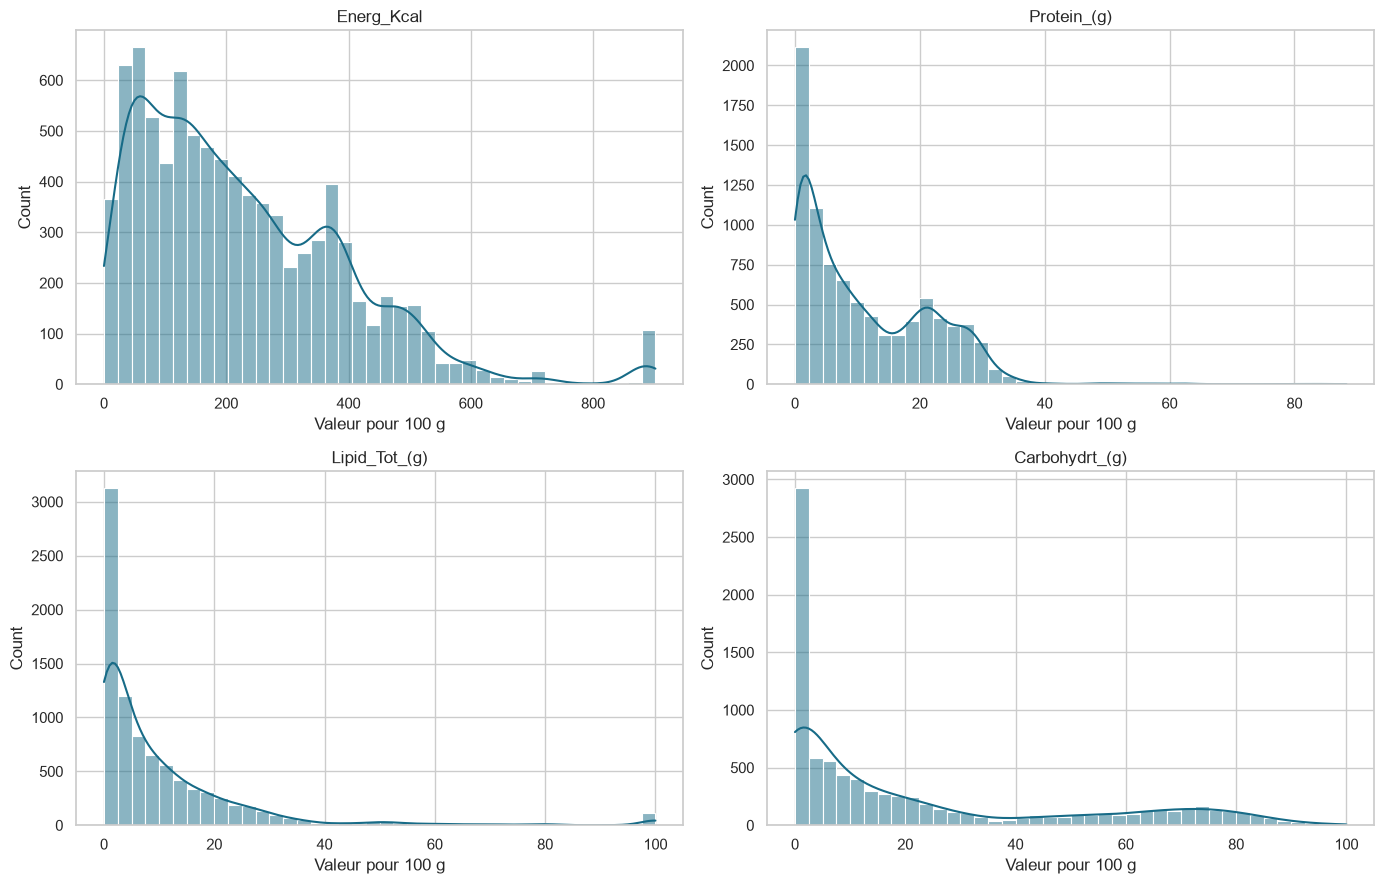

In [6]:
# 2. Distribution de l'énergie et des macronutriments.
plot_columns = [column for column in [
    "Energ_Kcal", "Protein_(g)", "Lipid_Tot_(g)", "Carbohydrt_(g)"
] if column in data]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, column in zip(axes.ravel(), plot_columns):
    sns.histplot(data[column].dropna(), bins=40, kde=True, ax=axis, color="#176b87")
    axis.set_title(column)
    axis.set_xlabel("Valeur pour 100 g")
plt.tight_layout()
plt.show()

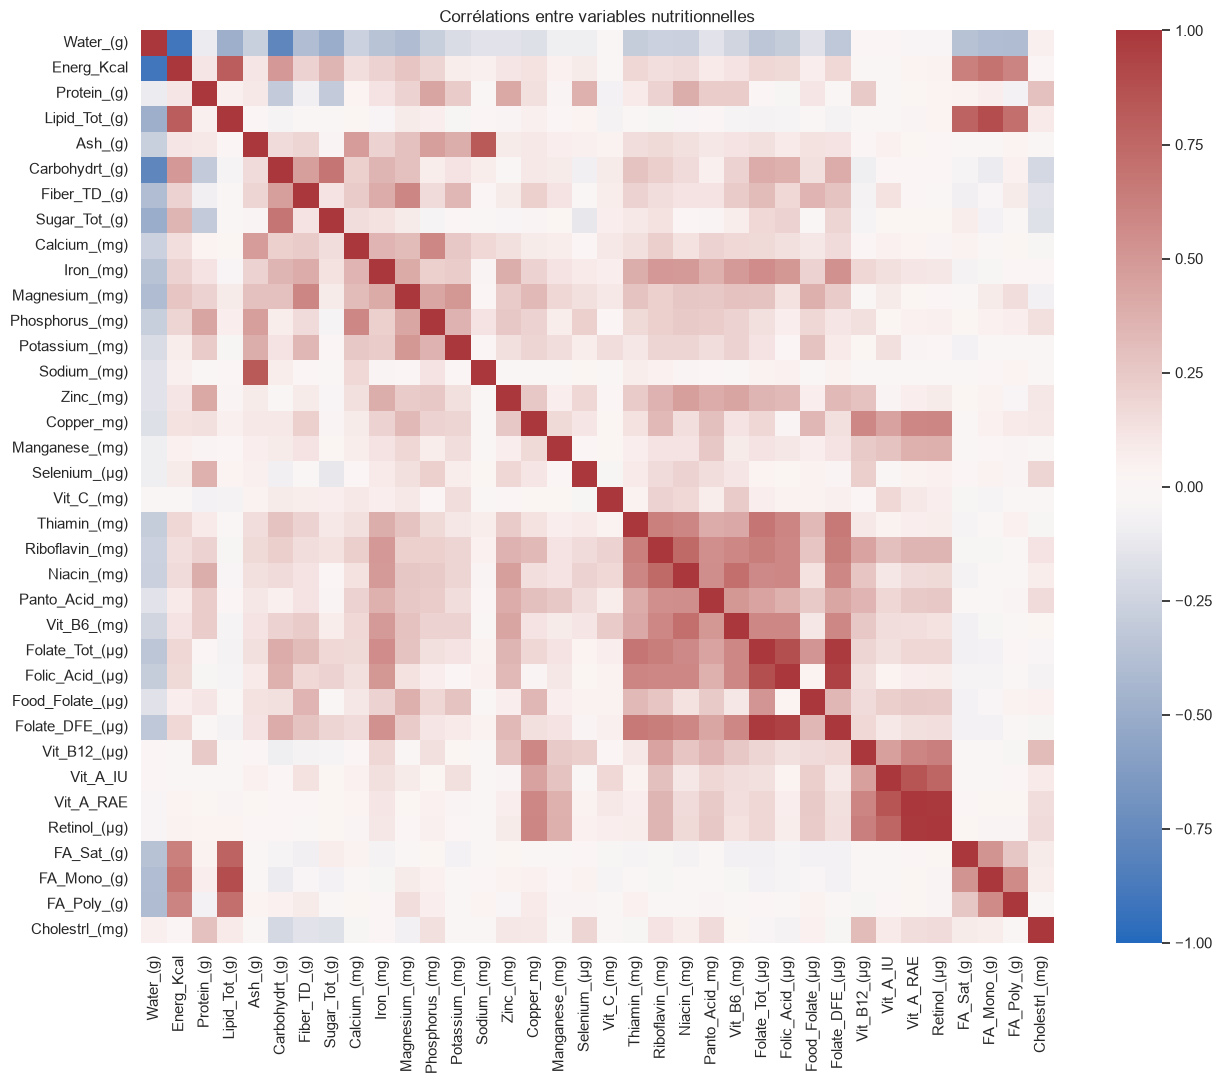

In [7]:
# 3. Associations entre variables : corrélations de Pearson.
correlation = data[acp_columns].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(correlation, cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Corrélations entre variables nutritionnelles")
plt.tight_layout()
plt.show()

In [8]:

# Associations les plus fortes en valeur absolue, hors diagonale.
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .rename("correlation")
    .sort_values(key=np.abs, ascending=False)
    .head(12)
    .to_frame()
)
display(pairs.round(3))

,,correlation
Vit_A_RAE,Retinol_(µg),0.989
Folate_Tot_(µg),Folate_DFE_(µg),0.983
Folic_Acid_(µg),Folate_DFE_(µg),0.952
Water_(g),Energ_Kcal,-0.901
Lipid_Tot_(g),FA_Mono_(g),0.885
Folate_Tot_(µg),Folic_Acid_(µg),0.880
Vit_A_IU,Vit_A_RAE,0.845
Ash_(g),Sodium_(mg),0.826
Energ_Kcal,Lipid_Tot_(g),0.807
Water_(g),Carbohydrt_(g),-0.774


,axe,variance_expliquee,variance_cumulee
0,PC1,20.52,20.52
1,PC2,11.52,32.04
2,PC3,10.01,42.05
3,PC4,7.24,49.29
4,PC5,7.05,56.35
5,PC6,4.74,61.08
6,PC7,3.79,64.87
7,PC8,3.39,68.26
8,PC9,2.83,71.08
9,PC10,2.68,73.76


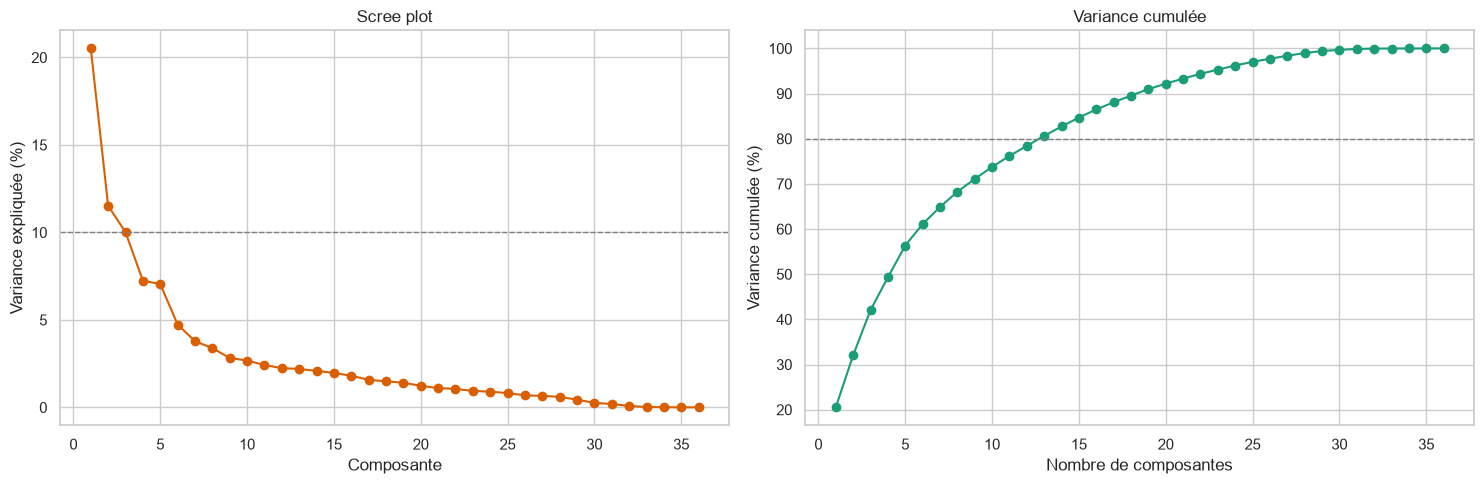

In [9]:

# 4. ACP sur données imputées puis standardisées.
pca = PCA()
coordinates = pca.fit_transform(acp_scaled)
explained = pd.DataFrame({
    "axe": [f"PC{i}" for i in range(1, len(pca.explained_variance_ratio_) + 1)],
    "variance_expliquee": pca.explained_variance_ratio_,
})
explained["variance_cumulee"] = explained["variance_expliquee"].cumsum()
display(explained.head(10).assign(
    variance_expliquee=lambda frame: (frame["variance_expliquee"] * 100).round(2),
    variance_cumulee=lambda frame: (frame["variance_cumulee"] * 100).round(2),
))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_ * 100, marker="o", color="#d95f02")
axes[0].set(xlabel="Composante", ylabel="Variance expliquée (%)", title="Scree plot")
axes[0].axhline(10, color="grey", linestyle="--", linewidth=1)
axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_.cumsum() * 100, marker="o", color="#1b9e77")
axes[1].set(xlabel="Nombre de composantes", ylabel="Variance cumulée (%)", title="Variance cumulée")
axes[1].axhline(80, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

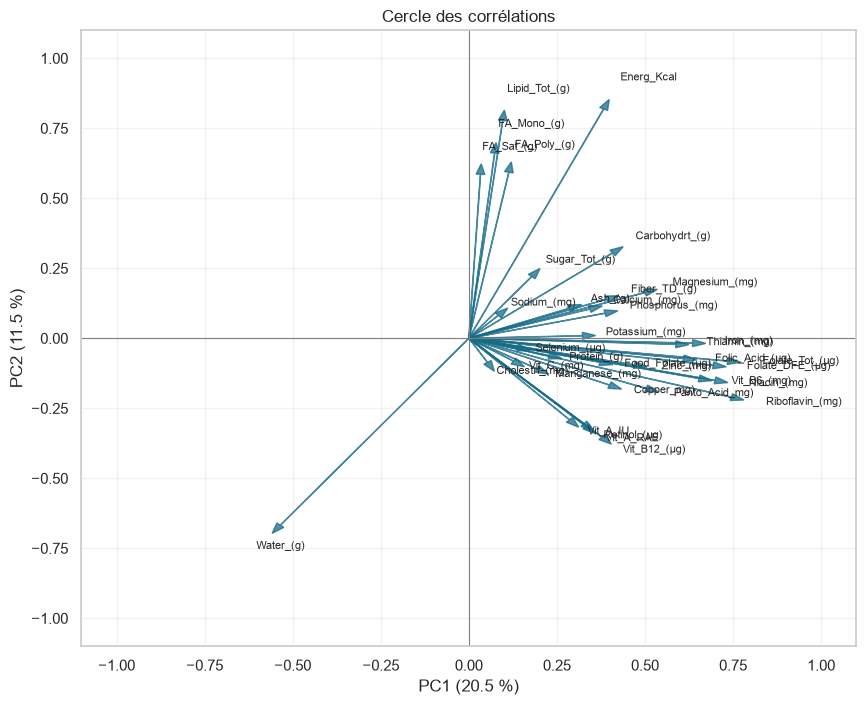

Variables les plus liées à chaque axe :

PC1


Riboflavin_(mg)    0.781
Folate_Tot_(µg)    0.772
Niacin_(mg)        0.736
Folate_DFE_(µg)    0.731
Vit_B6_(mg)        0.690
Iron_(mg)          0.672
Folic_Acid_(µg)    0.647
Thiamin_(mg)       0.625
Name: PC1, dtype: float64


PC2


Energ_Kcal       0.853
Lipid_Tot_(g)    0.815
FA_Mono_(g)      0.699
Water_(g)       -0.697
FA_Poly_(g)      0.630
FA_Sat_(g)       0.623
Vit_B12_(µg)    -0.378
Vit_A_RAE       -0.341
Name: PC2, dtype: float64

In [10]:
# Cercle des corrélations : contribution des variables aux deux premiers axes.
loadings = pd.DataFrame(
    pca.components_.T[:, :2] * np.sqrt(pca.explained_variance_[:2]),
    index=acp_columns,
    columns=["PC1", "PC2"],
)
plt.figure(figsize=(10, 8))
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
for variable, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"], row["PC2"], color="#176b87", alpha=0.75,
              head_width=0.025, length_includes_head=True)
    plt.text(row["PC1"] * 1.08, row["PC2"] * 1.08, variable, fontsize=8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f} %)")
plt.title("Cercle des corrélations")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(alpha=0.25)
plt.show()

print("Variables les plus liées à chaque axe :")
for axis in ["PC1", "PC2"]:
    print(f"\n{axis}")
    display(loadings[axis].sort_values(key=np.abs, ascending=False).head(8).round(3))

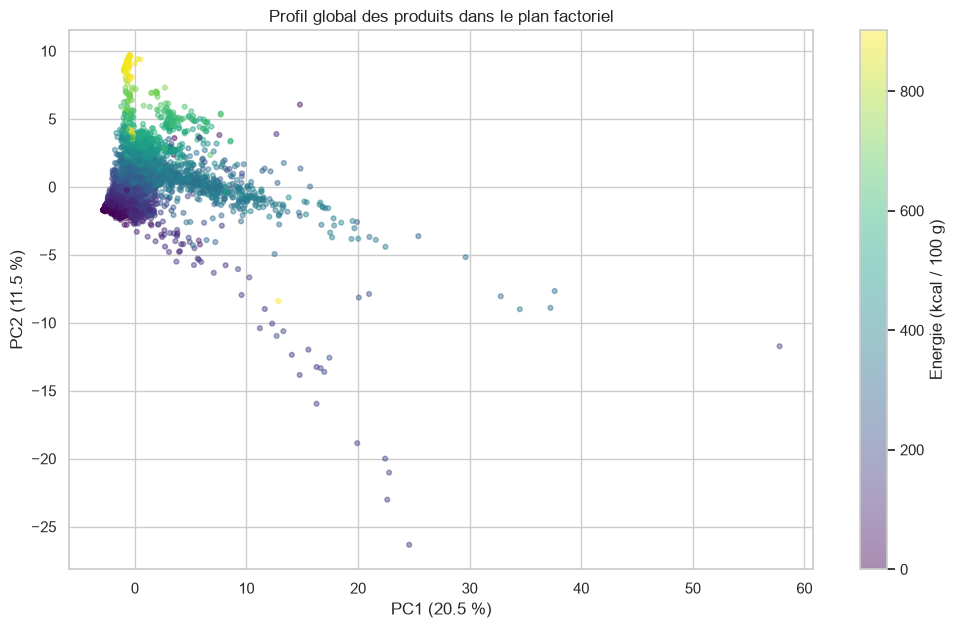

In [11]:
# Projection des produits dans le plan factoriel.
coordinates_df = pd.DataFrame(coordinates[:, :2], columns=["PC1", "PC2"])
coordinates_df["produit"] = data["Shrt_Desc"].values
coordinates_df["energie"] = data["Energ_Kcal"].values
plt.figure(figsize=(12, 7))
scatter = plt.scatter(coordinates_df["PC1"], coordinates_df["PC2"],
                      c=coordinates_df["energie"], cmap="viridis", s=12, alpha=0.45)
plt.colorbar(scatter, label="Energie (kcal / 100 g)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f} %)")
plt.title("Profil global des produits dans le plan factoriel")
plt.show()

In [12]:


# Produits extrêmes sur les deux premiers axes, utiles pour l'interprétation.
for axis in ["PC1", "PC2"]:
    print(f"\nProduits aux extrêmes de {axis} :")
    display(coordinates_df.loc[
        coordinates_df[axis].abs().nlargest(5).index,
        ["produit", axis, "energie"]
    ].sort_values(axis).reset_index(drop=True))

print("Conclusion : l'ACP résume les profils nutritionnels après imputation médiane et standardisation.")
print("Les variables ayant les plus grandes coordonnées sur PC1 et PC2 sont les principales dimensions de différenciation des produits.")


Produits aux extrêmes de PC1 :


,produit,PC1,energie
0,"CEREALS RTE,RALSTON ENR WHEAT BRAN FLAKES",32.788857,310
1,"CEREALS RTE,KELLOGG,KELLOGG'S PRODUCT 19",34.496006,374
2,"CEREALS RTE,KELLOGG,KELLOGG'S ALL-BRAN COMPLET...",37.240401,327
3,"CEREALS RTE,GENERAL MILLS,WHL GRAIN TOTAL",37.620952,320
4,YEAST EXTRACT SPREAD,57.773350,185



Produits aux extrêmes de PC2 :


,produit,PC2,energie
0,"BEEF,NZ,IMP,VAR MEATS & BY-PRODUCTS,LIVER,RAW",-26.334597,133
1,"BEEF,NZ,IMP,VAR MEATS & BY-PRODUCTS LIVER,CKD,BLD",-23.014270,150
2,"VEAL,VAR MEATS&BY-PRODUCTS,LIVER,CKD,BRSD",-21.025293,192
3,"VEAL,VAR MEATS&BY-PRODUCTS,LIVER,CKD,PAN-FRIED",-19.997252,193
4,"LAMB,NZ,IMP,LIVER,CKD,SOAKED & FRIED",-18.859479,168


Conclusion : l'ACP résume les profils nutritionnels après imputation médiane et standardisation.
Les variables ayant les plus grandes coordonnées sur PC1 et PC2 sont les principales dimensions de différenciation des produits.
